In [ ]:
!pip install xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 11.0 MB/s eta 0:00:00


**importation des bibliothèques et le train_test-split**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving fraud.csv to fraud.csv


In [ ]:
df = pd.read_csv("fraud.csv")

In [ ]:
df.head()

df.info()

df.describe()

df.shape

df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  FraudFound_P          15420 non-null

Index(['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea',
       'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex',
       'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory',
       'VehiclePrice', 'FraudFound_P', 'PolicyNumber', 'RepNumber',
       'Deductible', 'DriverRating', 'Days_Policy_Accident',
       'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle',
       'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year',
       'BasePolicy'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Month,0
WeekOfMonth,0
DayOfWeek,0
Make,0
AccidentArea,0
DayOfWeekClaimed,0
MonthClaimed,0
WeekOfMonthClaimed,0
Sex,0
MaritalStatus,0


In [ ]:
df.duplicated().sum()

np.int64(0)

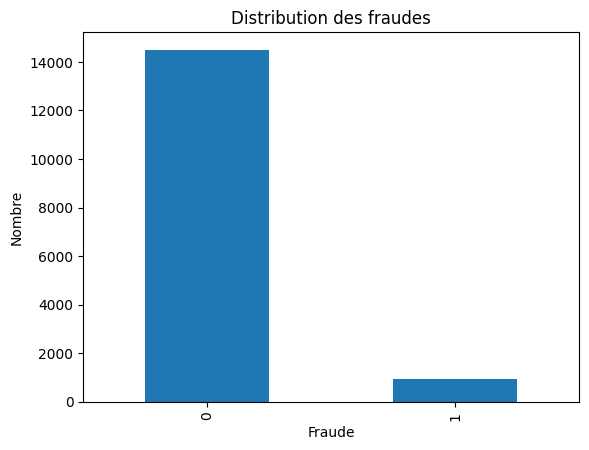

In [ ]:
import matplotlib.pyplot as plt

df["FraudFound_P"].value_counts().plot(kind="bar")

plt.title("Distribution des fraudes")
plt.xlabel("Fraude")
plt.ylabel("Nombre")
plt.show()

In [ ]:
df["FraudFound_P"].value_counts(normalize=True) * 100

,proportion
FraudFound_P,
0,94.014267
1,5.985733


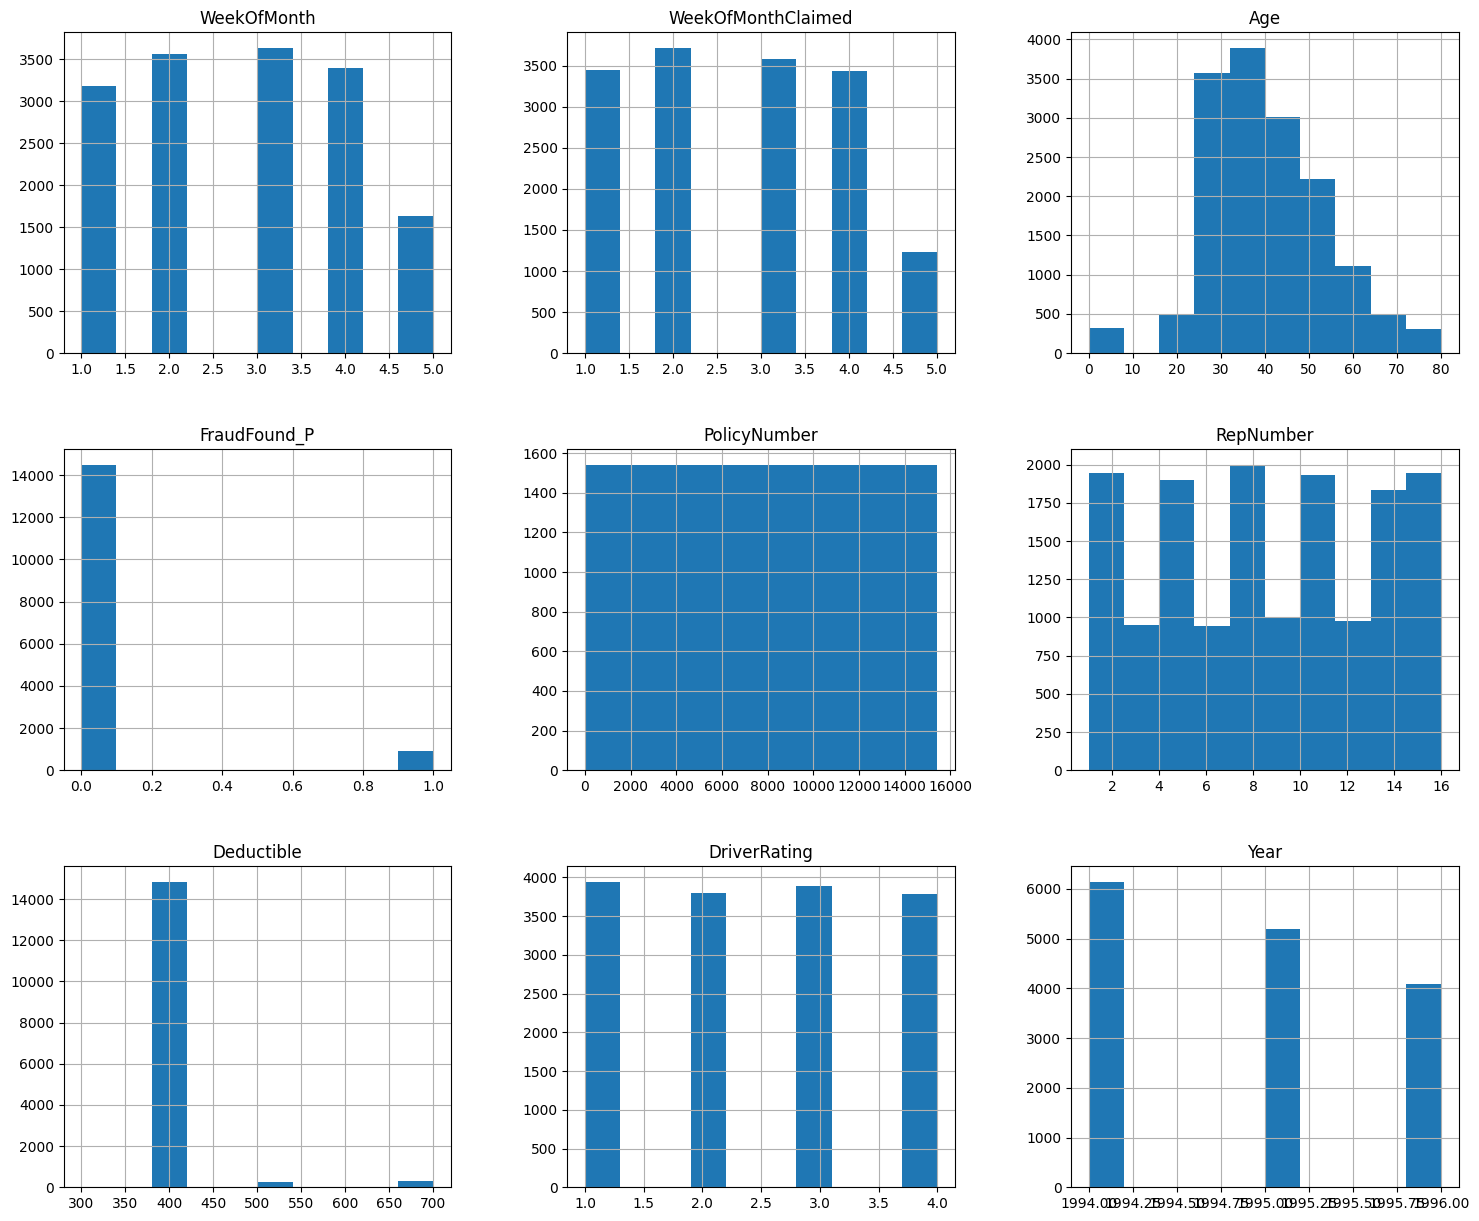

In [ ]:
df.hist(figsize=(18,15))
plt.show()

In [ ]:
X = df.drop("FraudFound_P", axis=1)

y = df["FraudFound_P"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (12336, 32)
X_test  : (3084, 32)
y_train : (12336,)
y_test  : (3084,)


In [ ]:
print("Train")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest")
print(y_test.value_counts(normalize=True) * 100)

Train
FraudFound_P
0    94.01751
1     5.98249
Name: proportion, dtype: float64

Test
FraudFound_P
0    94.001297
1     5.998703
Name: proportion, dtype: float64


In [ ]:
df.select_dtypes(include="object").columns

Index(['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed',
       'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType',
       'VehicleCategory', 'VehiclePrice', 'Days_Policy_Accident',
       'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle',
       'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars',
       'BasePolicy'],
      dtype='object')

**encodage des données catégorielles**

In [ ]:
X = df.drop("FraudFound_P", axis=1)
y = df["FraudFound_P"]

X = pd.get_dummies(
    X,
    drop_first=True
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Entrainement du modèle de base "Logistic_Regression"**


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000)

**Prédiction**

In [ ]:
y_pred = lr.predict(X_test_scaled)

**Affichage des Métriques du modèle**

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

Accuracy : 0.9406614785992218
Precision : 0.75
Recall : 0.016216216216216217
F1-score : 0.031746031746031744


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       0.75      0.02      0.03       185

    accuracy                           0.94      3084
   macro avg       0.85      0.51      0.50      3084
weighted avg       0.93      0.94      0.91      3084



In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.63      0.77      2899
           1       0.13      0.88      0.23       185

    accuracy                           0.64      3084
   macro avg       0.56      0.75      0.50      3084
weighted avg       0.94      0.64      0.74      3084



In [ ]:
results = X_test.copy()

results["Actual_Fraud"] = y_test.values
results["Predicted_Fraud"] = y_pred

In [ ]:
predicted_frauds = results[results["Predicted_Fraud"] == 1]

predicted_frauds.head(20)

,WeekOfMonth,WeekOfMonthClaimed,Age,PolicyNumber,RepNumber,Deductible,DriverRating,Year,Month_Aug,Month_Dec,...,AddressChange_Claim_no change,AddressChange_Claim_under 6 months,NumberOfCars_2 vehicles,NumberOfCars_3 to 4,NumberOfCars_5 to 8,NumberOfCars_more than 8,BasePolicy_Collision,BasePolicy_Liability,Actual_Fraud,Predicted_Fraud
4274,2,3,23,4275,12,400,2,1994,False,False,...,True,False,False,False,False,False,False,False,0,1
10675,1,3,43,10676,3,400,3,1995,False,False,...,True,False,False,False,False,False,True,False,0,1
11043,4,5,51,11044,1,400,1,1995,False,False,...,True,False,False,False,False,False,False,False,0,1
9299,3,1,35,9300,9,400,1,1995,False,False,...,True,False,False,False,False,False,False,False,1,1
4168,5,2,37,4169,16,400,4,1994,False,False,...,True,False,False,False,False,False,False,False,0,1
5550,3,3,37,5551,15,400,4,1994,False,False,...,True,False,False,False,False,False,True,False,0,1
3531,3,5,45,3532,4,400,3,1994,False,False,...,True,False,False,False,False,False,False,False,0,1
4396,1,4,50,4397,8,400,2,1994,False,True,...,True,False,False,False,False,False,True,False,0,1
3256,5,5,46,3257,8,400,4,1994,False,False,...,True,False,False,False,False,False,False,False,0,1
3736,1,3,63,3737,4,400,4,1994,False,False,...,True,False,False,False,False,False,False,False,0,1


In [ ]:
tp = ((results["Actual_Fraud"] == 1) &
      (results["Predicted_Fraud"] == 1)).sum()

fp = ((results["Actual_Fraud"] == 0) &
      (results["Predicted_Fraud"] == 1)).sum()

fn = ((results["Actual_Fraud"] == 1) &
      (results["Predicted_Fraud"] == 0)).sum()

tn = ((results["Actual_Fraud"] == 0) &
      (results["Predicted_Fraud"] == 0)).sum()

print("True Positives (fraudes détectées) :", tp)
print("False Positives (fausses alertes) :", fp)
print("False Negatives (fraudes manquées) :", fn)
print("True Negatives (cas normaux) :", tn)

True Positives (fraudes détectées) : 162
False Positives (fausses alertes) : 1077
False Negatives (fraudes manquées) : 23
True Negatives (cas normaux) : 1822


**"Le Modèle "Decision_Tree"**


In [ ]:
dt = DecisionTreeClassifier(
    random_state=42
)

In [ ]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_dt = dt.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.96      0.95      0.95      2899
           1       0.31      0.36      0.33       185

    accuracy                           0.91      3084
   macro avg       0.63      0.66      0.64      3084
weighted avg       0.92      0.91      0.92      3084



In [ ]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_dt).ravel()

print("True Positives :", tp)
print("False Positives :", fp)
print("False Negatives :", fn)
print("True Negatives :", tn)

True Positives : 67
False Positives : 150
False Negatives : 118
True Negatives : 2749


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

**Le modèle Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_rf))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()

print("TP :", tp)
print("FP :", fp)
print("FN :", fn)
print("TN :", tn)

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       1.00      0.01      0.01       185

    accuracy                           0.94      3084
   macro avg       0.97      0.50      0.49      3084
weighted avg       0.94      0.94      0.91      3084

TP : 1
FP : 0
FN : 184
TN : 2899


In [ ]:
y_train.value_counts()

,count
FraudFound_P,
0,11598
1,738


In [ ]:
y_train.value_counts(normalize=True) * 100

,proportion
FraudFound_P,
0,94.01751
1,5.98249


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced_subsample",
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96      2899
           1       0.37      0.17      0.24       185

    accuracy                           0.93      3084
   macro avg       0.66      0.58      0.60      3084
weighted avg       0.91      0.93      0.92      3084



In [ ]:
predictions = X_test.copy()

predictions["Actual_Fraud"] = y_test.values
predictions["Predicted_Fraud"] = y_pred_rf

In [ ]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()

print("True Positives (fraudes détectées) :", tp)
print("False Positives (fausses alertes) :", fp)
print("False Negatives (fraudes manquées) :", fn)
print("True Negatives (cas normaux) :", tn)

True Positives (fraudes détectées) : 32
False Positives (fausses alertes) : 54
False Negatives (fraudes manquées) : 153
True Negatives (cas normaux) : 2845


**Importation de XGboost**

In [ ]:
from xgboost import XGBClassifier

**Calcul du poids de la classe positive**

In [ ]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

print(scale_pos_weight)

15.715447154471544


In [ ]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

**ENTRAINEMENT DU XGCB (gradiant boosting)**

In [ ]:
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      2899
           1       0.53      0.83      0.64       185

    accuracy                           0.95      3084
   macro avg       0.76      0.89      0.81      3084
weighted avg       0.96      0.95      0.95      3084



In [ ]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_xgb).ravel()

print("True Positives (fraudes détectées) :", tp)
print("False Positives (fausses alertes) :", fp)
print("False Negatives (fraudes manquées) :", fn)
print("True Negatives (cas normaux) :", tn)

True Positives (fraudes détectées) : 153
False Positives (fausses alertes) : 137
False Negatives (fraudes manquées) : 32
True Negatives (cas normaux) : 2762


**Lightgbm**

In [101]:
!pip install lightgbm

In [102]:
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

lgb.fit(X_train, y_train)

y_pred_lgb = lgb.predict(X_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 738, number of negative: 11598
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008047 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 566
[LightGBM] [Info] Number of data points in the train set: 12336, number of used features: 109
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.059825 -> initscore=-2.754644
[LightGBM] [Info] Start training from score -2.754644


In [103]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lgb))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      2899
           1       0.87      0.22      0.35       185

    accuracy                           0.95      3084
   macro avg       0.91      0.61      0.66      3084
weighted avg       0.95      0.95      0.94      3084



In [104]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lgb).ravel()

print("True Positives :", tp)
print("False Positives :", fp)
print("False Negatives :", fn)
print("True Negatives :", tn)

True Positives : 41
False Positives : 6
False Negatives : 144
True Negatives : 2893


In [105]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lgb).ravel()

print("True Positives (fraudes détectées) :", tp)
print("False Positives (fausses alertes) :", fp)
print("False Negatives (fraudes manquées) :", fn)
print("True Negatives (cas normaux) :", tn)

True Positives (fraudes détectées) : 41
False Positives (fausses alertes) : 6
False Negatives (fraudes manquées) : 144
True Negatives (cas normaux) : 2893


**Le modèle de CatBoost**

In [106]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    verbose=0,
    random_state=42
)

cat.fit(X_train, y_train)

y_pred_cat = cat.predict(X_test)

In [107]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_cat).ravel()

print("True Positives (fraudes détectées) :", tp)
print("False Positives (fausses alertes) :", fp)
print("False Negatives (fraudes manquées) :", fn)
print("True Negatives (cas normaux) :", tn)

True Positives (fraudes détectées) : 24
False Positives (fausses alertes) : 1
False Negatives (fraudes manquées) : 161
True Negatives (cas normaux) : 2898


**la capacité golbale du modèle**

In [108]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_proba = xgb.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_proba)

print("ROC-AUC :", auc)

ROC-AUC : 0.9631746268517569


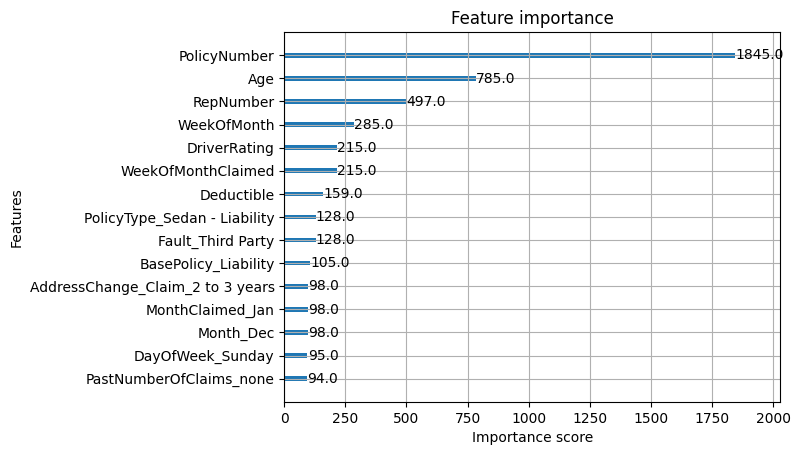

In [111]:
import xgboost as xgb_plot
import matplotlib.pyplot as plt

xgb_plot.plot_importance(
    xgb,
    max_num_features=15
)

plt.show()

In [112]:
y_proba_xgb = xgb.predict_proba(X_test)[:,1]

In [113]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_test,
    y_proba_xgb
)

print("ROC-AUC :", auc)

ROC-AUC : 0.9631746268517569


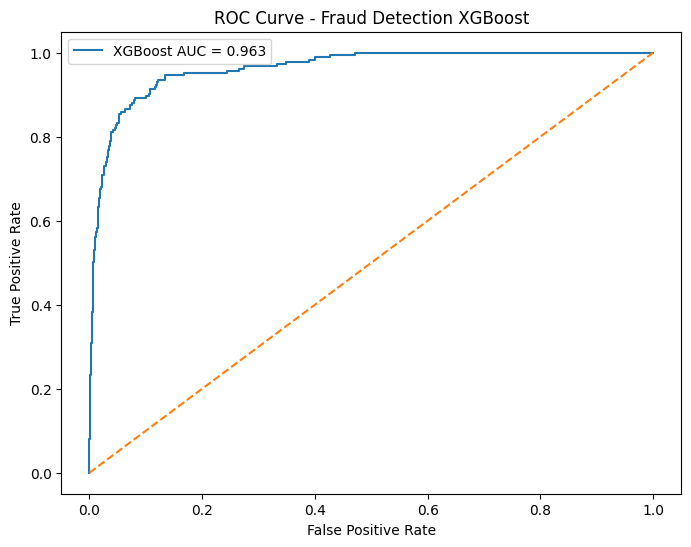

In [114]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_proba_xgb
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Fraud Detection XGBoost")
plt.legend()
plt.show()

In [115]:
import joblib

joblib.dump(
    xgb,
    "chaabi_lld_fraud_detection_xgb.pkl"
)

['chaabi_lld_fraud_detection_xgb.pkl']

In [116]:
!pip install streamlit
!pip install pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 52.2 MB/s eta 0:00:00


In [117]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib


# Charger le modèle
model = joblib.load("fraud_detection_xgb.pkl")


st.title("🚗 Chaabi LLD - Fraud Detection AI")

st.write(
    "Application de détection de fraude basée sur XGBoost"
)


st.sidebar.header("Informations du dossier")


# Exemple avec tes variables principales

Month = st.sidebar.number_input("Month", 0, 12, 1)
Make = st.sidebar.number_input("Make", 0, 10, 1)
AccidentArea = st.sidebar.number_input("Accident Area", 0, 5, 1)
Sex = st.sidebar.number_input("Sex", 0, 5, 1)
MaritalStatus = st.sidebar.number_input("Marital Status", 0, 5, 1)
BasePolicy = st.sidebar.number_input("Base Policy", 0, 5, 1)


if st.button("Predict Fraud"):

    data = pd.DataFrame({
        "Month":[Month],
        "Make":[Make],
        "AccidentArea":[AccidentArea],
        "Sex":[Sex],
        "MaritalStatus":[MaritalStatus],
        "BasePolicy":[BasePolicy]
    })


    prediction = model.predict(data)

    probability = model.predict_proba(data)[0][1]


    st.subheader("Résultat")


    if prediction[0] == 1:
        st.error(
            f"⚠️ Fraude détectée\nProbabilité : {probability:.2%}"
        )

    else:
        st.success(
            f"✅ Dossier normal\nProbabilité fraude : {probability:.2%}"
        )

Writing app.py


In [118]:
!pip install ngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 12.6 MB/s eta 0:00:00


In [121]:
!ngrok config add-authtoken 3GDfAOZLsE3gqD1I6HS7KOkINVd_r2fkWvrm1B7Mw2Z6P31u

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [124]:
!ps aux | grep streamlit

root       28765  0.0  0.0   7372  3520 ?        S    11:46   0:00 /bin/bash -c ps aux | grep streamlit
root       28767  0.0  0.0   6480  2536 ?        S    11:46   0:00 grep streamlit


In [126]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

In [123]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://vessel-halogen-duckling.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
!./cloudflared tunnel --url http://localhost:8501

2026-07-08T11:52:08Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-07-08T11:52:08Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-07-08T11:52:14Z INF +--------------------------------------------------------------------------------------------+
2026-07-08T11:52:14Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-07-08T11:52:14Z INF |  https://accepted-img-municipality-trek.trycloudflare.

In [ ]:
!ps aux | grep streamlit

In [ ]:
!curl http://localhost:8501 